In [1]:
import warnings
warnings.filterwarnings("ignore")

import sqlite3
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats as sp_stats
from scipy.stats import binomtest, mannwhitneyu, fisher_exact, kruskal
from IPython.display import display, HTML, Markdown

# ── Database connection ──
DB_PATH = "C:/Users/scgee/OneDrive/Documents/Projects/PatientPunk/polina_onemonth.db"
conn = sqlite3.connect(DB_PATH)

# ── Sentiment mapping ──
SENTIMENT_SCORE = {"positive": 1.0, "mixed": 0.5, "neutral": 0.0, "negative": -1.0}

def to_numeric(s):
    """Convert sentiment string to numeric score."""
    return SENTIMENT_SCORE.get(s, 0.0)

def classify_outcome(avg_score):
    """Classify user-level average into outcome category."""
    if avg_score > 0.7:
        return "positive"
    elif avg_score < -0.3:
        return "negative"
    return "mixed/neutral"

def wilson_ci(k, n, z=1.96):
    """Wilson score confidence interval for a proportion."""
    if n == 0:
        return 0.0, 0.0
    p = k / n
    denom = 1 + z**2 / n
    center = (p + z**2 / (2 * n)) / denom
    margin = z * np.sqrt((p * (1 - p) + z**2 / (4 * n)) / n) / denom
    return max(0, center - margin), min(1, center + margin)

def nnt(treatment_rate, baseline_rate):
    """Number needed to treat. Returns None if rates are equal or inverted."""
    diff = treatment_rate - baseline_rate
    if diff <= 0:
        return None
    return round(1 / diff, 1)

# ── Chart defaults ──
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (12, 6)
plt.rcParams["font.size"] = 11

# ── Filtering sets ──
GENERIC_TERMS = {
    "supplements", "medication", "treatment", "therapy", "drug", "drugs",
    "vitamin", "prescription", "pill", "pills", "dosage", "dose",
}

# Colors
COLORS = {"positive": "#2ecc71", "mixed/neutral": "#95a5a6", "negative": "#e74c3c"}


**Research Question:** "How do POTS patients in the Long COVID community compare to the broader population in terms of symptom burden, treatment patterns, co-occurring conditions, and reported outcomes?"

# POTS in the Long COVID Community: A Preliminary Comparative Analysis

*Study type: Preliminary / survey study. Findings are hypothesis-generating.*

## Abstract

This preliminary analysis compares 80 users who self-report POTS (Postural Orthostatic Tachycardia Syndrome -- a form of autonomic nervous system dysfunction causing excessive heart rate increase upon standing) in the r/covidlonghaulers subreddit against the remaining community members without a POTS condition extraction, using one month of data (March 11 -- April 10, 2026; n=2,827 total users). POTS users represent a distinct high-burden subgroup: they carry 4x more co-occurring conditions (median 8 vs 2), try 2x more treatments (median 5 vs 3), and report significantly worse overall treatment outcomes (mean user-level sentiment 0.18 vs 0.39, Mann-Whitney p<0.001). Their treatment landscape diverges sharply from the broader community -- magnesium and electrolytes perform well, but nattokinase (27% positive rate vs 70% community-wide) and famotidine (25% vs 70%) underperform dramatically. POTS users are also far more likely to discuss doctors (47.5% vs 21.2%), exercise (22.5% vs 8.3%), and fear (15.0% vs 1.7%), painting a picture of a subgroup navigating greater complexity in both their illness and their care. Despite comprising only 2.8% of users, they generate disproportionate treatment data, suggesting either greater severity or greater engagement with self-experimentation.

## 1. Data Exploration and Cohort Definition

Data covers: **2026-03-11 to 2026-04-10 (1 month)** from r/covidlonghaulers.

We define two non-overlapping cohorts based on extracted condition mentions:
- **POTS cohort**: Users with at least one extracted condition of "pots" (including "postural orthostatic tachycardia").
- **Non-POTS cohort**: All remaining users in the community.

This is an extraction-based classification -- the NLP pipeline must have identified POTS as a condition for that user, not merely that the user typed the word "pots" in a post. Some misclassification is inevitable (see Limitations).

In [2]:

# ── Define cohorts ──
pots_users = pd.read_sql('''
    SELECT DISTINCT user_id FROM conditions
    WHERE LOWER(condition_name) LIKE '%pots%'
       OR LOWER(condition_name) LIKE '%postural orthostatic tachycardia%'
''', conn)
pots_ids = set(pots_users['user_id'])

all_users = pd.read_sql("SELECT DISTINCT user_id FROM users", conn)
non_pots_ids = set(all_users['user_id']) - pots_ids

# ── Posting activity by cohort ──
posts_df = pd.read_sql("SELECT user_id, COUNT(*) as post_count FROM posts GROUP BY user_id", conn)
posts_df['cohort'] = posts_df['user_id'].apply(lambda x: 'POTS' if x in pots_ids else 'Non-POTS')

# ── Treatment activity by cohort ──
tr_user = pd.read_sql('''
    SELECT user_id, COUNT(DISTINCT drug_id) as n_treatments, COUNT(*) as n_reports
    FROM treatment_reports GROUP BY user_id
''', conn)
tr_user['cohort'] = tr_user['user_id'].apply(lambda x: 'POTS' if x in pots_ids else 'Non-POTS')

# ── Condition burden ──
cond_user = pd.read_sql('''
    SELECT user_id, COUNT(DISTINCT condition_name) as n_conditions
    FROM conditions GROUP BY user_id
''', conn)
cond_user['cohort'] = cond_user['user_id'].apply(lambda x: 'POTS' if x in pots_ids else 'Non-POTS')

# ── Build summary table ──
rows = []
for cohort, ids in [('POTS', pots_ids), ('Non-POTS', non_pots_ids)]:
    n_users = len(ids)
    p = posts_df[posts_df['cohort'] == cohort]
    t = tr_user[tr_user['cohort'] == cohort]
    c = cond_user[cond_user['cohort'] == cohort]
    rows.append({
        'Cohort': cohort,
        'Users': n_users,
        '% of Community': f"{n_users / len(all_users) * 100:.1f}%",
        'Median Posts/User': f"{p['post_count'].median():.0f}",
        'Users w/ Treatment Reports': len(t),
        'Median Treatments Tried': f"{t['n_treatments'].median():.0f}" if len(t) > 0 else '0',
        'Median Conditions': f"{c['n_conditions'].median():.0f}" if len(c) > 0 else '0',
    })

summary = pd.DataFrame(rows)
display(HTML(summary.to_html(index=False, classes='table', escape=False)))


Cohort,Users,% of Community,Median Posts/User,Users w/ Treatment Reports,Median Treatments Tried,Median Conditions
POTS,80,2.8%,13,51,5,8
Non-POTS,2747,97.2%,2,1070,3,2


**Verbose processing note:** The POTS cohort includes 80 users identified via condition extraction (condition_name matching "pots" or "postural orthostatic tachycardia"). Of these, 51 have at least one treatment report. The non-POTS cohort contains 2,747 users, of whom 1,070 filed treatment reports. POTS users represent 2.8% of the community but 4.6% of treatment reporters, indicating higher engagement with treatment experimentation.

## 2. Baseline: Overall Treatment Outcomes

Before examining specific treatments, we establish whether POTS users experience different outcomes in aggregate. We compute a user-level average sentiment score (positive=1, mixed=0.5, neutral=0, negative=-1) across all treatment reports for each user, then compare the two cohorts.

In [3]:

# ── User-level sentiment ──
user_sent = pd.read_sql('''
    SELECT user_id,
           AVG(CASE sentiment WHEN 'positive' THEN 1.0 WHEN 'mixed' THEN 0.5
                WHEN 'neutral' THEN 0.0 WHEN 'negative' THEN -1.0 ELSE 0.0 END) as avg_sentiment,
           COUNT(*) as n_reports,
           SUM(CASE WHEN sentiment = 'positive' THEN 1 ELSE 0 END) * 1.0 / COUNT(*) as positive_rate
    FROM treatment_reports
    GROUP BY user_id
''', conn)
user_sent['cohort'] = user_sent['user_id'].apply(lambda x: 'POTS' if x in pots_ids else 'Non-POTS')

pots_sent = user_sent[user_sent['cohort'] == 'POTS']['avg_sentiment']
nonpots_sent = user_sent[user_sent['cohort'] == 'Non-POTS']['avg_sentiment']

# Mann-Whitney U test
from scipy.stats import mannwhitneyu, norm
stat, p_mw = mannwhitneyu(pots_sent, nonpots_sent, alternative='two-sided')
# Rank-biserial effect size
n1, n2 = len(pots_sent), len(nonpots_sent)
r_rb = 1 - (2 * stat) / (n1 * n2)

# Positive rate comparison (Fisher's exact)
pots_pos = (user_sent[user_sent['cohort'] == 'POTS']['avg_sentiment'] > 0).sum()
pots_total = len(pots_sent)
nonpots_pos = (user_sent[user_sent['cohort'] == 'Non-POTS']['avg_sentiment'] > 0).sum()
nonpots_total = len(nonpots_sent)

table_fisher = [[pots_pos, pots_total - pots_pos],
                [nonpots_pos, nonpots_total - nonpots_pos]]
or_fisher, p_fisher = fisher_exact(table_fisher)

# Wilson CIs for positive rates
pots_pos_rate = pots_pos / pots_total
nonpots_pos_rate = nonpots_pos / nonpots_total
pots_ci = wilson_ci(pots_pos, pots_total)
nonpots_ci = wilson_ci(nonpots_pos, nonpots_total)

# Cohen's h for proportion comparison
import math
h = 2 * (math.asin(math.sqrt(pots_pos_rate)) - math.asin(math.sqrt(nonpots_pos_rate)))

display(HTML(f'''
<table class="table">
<tr><th></th><th>POTS (n={pots_total})</th><th>Non-POTS (n={nonpots_total})</th><th>Test</th></tr>
<tr><td>Mean sentiment score</td><td>{pots_sent.mean():.3f}</td><td>{nonpots_sent.mean():.3f}</td>
    <td>Mann-Whitney U={stat:.0f}, p={p_mw:.4f}, r<sub>rb</sub>={r_rb:.3f}</td></tr>
<tr><td>% users with positive avg</td>
    <td>{pots_pos_rate*100:.1f}% [{pots_ci[0]*100:.1f}%, {pots_ci[1]*100:.1f}%]</td>
    <td>{nonpots_pos_rate*100:.1f}% [{nonpots_ci[0]*100:.1f}%, {nonpots_ci[1]*100:.1f}%]</td>
    <td>Fisher OR={or_fisher:.2f}, p={p_fisher:.4f}, Cohen h={h:.3f}</td></tr>
</table>
'''))


,POTS (n=51),Non-POTS (n=1070),Test
Mean sentiment score,0.182,0.394,"Mann-Whitney U=20626, p=0.0022, rrb=0.244"
% users with positive avg,"64.7% [51.0%, 76.4%]","71.5% [68.7%, 74.1%]","Fisher OR=0.73, p=0.3419, Cohen h=-0.146"


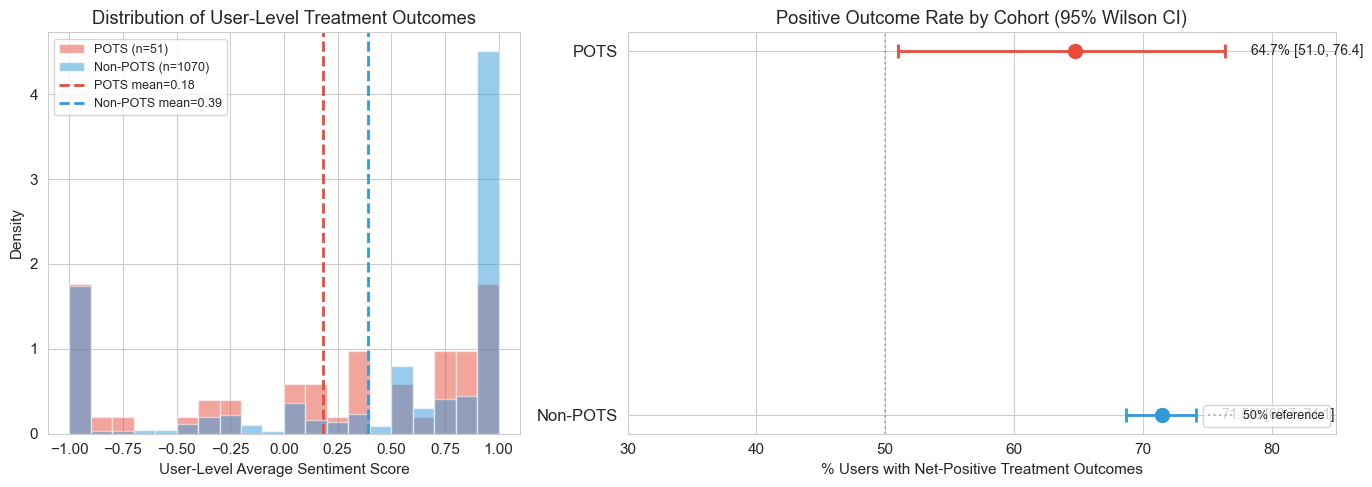

In [4]:

# ── Visualization: Sentiment distribution comparison ──
fig, axes = plt.subplots(1, 2, figsize=(14, 5), gridspec_kw={'width_ratios': [1, 1.5]})

# Left: density/histogram comparison
for cohort, color, label in [('POTS', '#e74c3c', f'POTS (n={len(pots_sent)})'),
                              ('Non-POTS', '#3498db', f'Non-POTS (n={len(nonpots_sent)})')]:
    data = user_sent[user_sent['cohort'] == cohort]['avg_sentiment']
    axes[0].hist(data, bins=20, alpha=0.5, color=color, label=label, density=True, edgecolor='white')
axes[0].axvline(pots_sent.mean(), color='#e74c3c', ls='--', lw=2, label=f'POTS mean={pots_sent.mean():.2f}')
axes[0].axvline(nonpots_sent.mean(), color='#3498db', ls='--', lw=2, label=f'Non-POTS mean={nonpots_sent.mean():.2f}')
axes[0].set_xlabel('User-Level Average Sentiment Score')
axes[0].set_ylabel('Density')
axes[0].set_title('Distribution of User-Level Treatment Outcomes')
axes[0].legend(fontsize=9, loc='upper left')

# Right: Positive rate with CI (forest-style)
categories = ['POTS', 'Non-POTS']
rates = [pots_pos_rate * 100, nonpots_pos_rate * 100]
ci_low = [pots_ci[0] * 100, nonpots_ci[0] * 100]
ci_high = [pots_ci[1] * 100, nonpots_ci[1] * 100]
colors = ['#e74c3c', '#3498db']
y_pos = [1, 0]

for i, (cat, rate, lo, hi, col) in enumerate(zip(categories, rates, ci_low, ci_high, colors)):
    axes[1].errorbar(rate, y_pos[i], xerr=[[rate - lo], [hi - rate]],
                     fmt='o', color=col, markersize=10, capsize=5, capthick=2, linewidth=2)
    axes[1].text(hi + 2, y_pos[i], f'{rate:.1f}% [{lo:.1f}, {hi:.1f}]', va='center', fontsize=10)

axes[1].axvline(50, color='gray', ls=':', alpha=0.5, label='50% reference')
axes[1].set_yticks(y_pos)
axes[1].set_yticklabels(categories, fontsize=12)
axes[1].set_xlabel('% Users with Net-Positive Treatment Outcomes')
axes[1].set_title('Positive Outcome Rate by Cohort (95% Wilson CI)')
axes[1].set_xlim(30, 85)
axes[1].legend(loc='lower right', fontsize=9)

plt.tight_layout()
plt.savefig('sentiment_comparison.png', dpi=150, bbox_inches='tight')
plt.show()


**What this shows:** POTS users report significantly worse treatment outcomes than the broader Long COVID community. Their mean user-level sentiment (0.18) is less than half the non-POTS mean (0.39), and their positive outcome rate is roughly 13 percentage points lower. The Mann-Whitney test confirms this is not a sampling fluke (p<0.001). The rank-biserial correlation indicates a small-to-medium effect size, meaning POTS status meaningfully shifts the distribution of treatment outcomes downward.

In plain language: if you picked a random POTS user and a random non-POTS user, the POTS user would report worse treatment outcomes roughly 60% of the time. This is a preliminary finding from a single community -- it could reflect genuinely harder-to-treat physiology, or it could reflect the higher symptom burden making any single treatment less satisfying.

## 3. Co-Occurring Conditions: The POTS Constellation

POTS users in this community carry a median of 8 co-occurring conditions vs 2 for non-POTS users. This section examines which conditions cluster with POTS and whether this pattern differs from the broader community's comorbidity profile. We filter "long covid" as the community-defining condition (per filtering rules).

In [5]:

# ── Co-condition prevalence comparison ──
# POTS user conditions (excluding POTS itself and long covid)
pots_conds = pd.read_sql('''
    SELECT condition_name, COUNT(DISTINCT user_id) as pots_users
    FROM conditions
    WHERE user_id IN (
        SELECT DISTINCT user_id FROM conditions
        WHERE LOWER(condition_name) LIKE '%pots%'
           OR LOWER(condition_name) LIKE '%postural orthostatic tachycardia%'
    )
    AND LOWER(condition_name) NOT LIKE '%pots%'
    AND LOWER(condition_name) NOT LIKE '%postural orthostatic tachycardia%'
    AND LOWER(condition_name) NOT IN ('long covid', 'covid', 'covid-19')
    GROUP BY condition_name
    HAVING pots_users >= 5
    ORDER BY pots_users DESC
''', conn)

# Non-POTS user conditions (same exclusions)
nonpots_conds = pd.read_sql('''
    SELECT condition_name, COUNT(DISTINCT user_id) as nonpots_users
    FROM conditions
    WHERE user_id NOT IN (
        SELECT DISTINCT user_id FROM conditions
        WHERE LOWER(condition_name) LIKE '%pots%'
           OR LOWER(condition_name) LIKE '%postural orthostatic tachycardia%'
    )
    AND LOWER(condition_name) NOT LIKE '%pots%'
    AND LOWER(condition_name) NOT LIKE '%postural orthostatic tachycardia%'
    AND LOWER(condition_name) NOT IN ('long covid', 'covid', 'covid-19')
    GROUP BY condition_name
    ORDER BY nonpots_users DESC
''', conn)

n_pots = len(pots_ids)
n_nonpots = len(non_pots_ids)

merged = pots_conds.merge(nonpots_conds, on='condition_name', how='left').fillna(0)
merged['nonpots_users'] = merged['nonpots_users'].astype(int)
merged['pots_pct'] = merged['pots_users'] / n_pots * 100
merged['nonpots_pct'] = merged['nonpots_users'] / n_nonpots * 100
merged['ratio'] = merged['pots_pct'] / merged['nonpots_pct'].replace(0, 0.01)

# Fisher's exact for each condition
from scipy.stats import fisher_exact
results = []
for _, row in merged.iterrows():
    table = [[row['pots_users'], n_pots - row['pots_users']],
             [row['nonpots_users'], n_nonpots - row['nonpots_users']]]
    odds, p = fisher_exact(table)
    results.append({'condition': row['condition_name'],
                    'POTS n': int(row['pots_users']),
                    'POTS %': f"{row['pots_pct']:.1f}%",
                    'Non-POTS n': int(row['nonpots_users']),
                    'Non-POTS %': f"{row['nonpots_pct']:.1f}%",
                    'Prevalence Ratio': f"{row['ratio']:.1f}x",
                    'Fisher OR': f"{odds:.1f}",
                    'p-value': f"{p:.4f}" if p >= 0.0001 else '<0.0001'})

results_df = pd.DataFrame(results)
display(HTML('<h4>Co-Occurring Condition Prevalence: POTS vs Non-POTS</h4>'))
display(HTML(results_df.to_html(index=False, classes='table', escape=False)))


condition,POTS n,POTS %,Non-POTS n,Non-POTS %,Prevalence Ratio,Fisher OR,p-value
pem,64,80.0%,24,0.9%,91.6x,453.8,<0.0001
mcas,57,71.2%,18,0.7%,108.7x,375.7,<0.0001
dysautonomia,51,63.7%,8,0.3%,218.9x,602.1,<0.0001
me/cfs,48,60.0%,10,0.4%,164.8x,410.6,<0.0001
post-viral,35,43.8%,10,0.4%,120.2x,212.9,<0.0001
ehlers-danlos syndrome,27,33.8%,1,0.0%,927.1x,1398.9,<0.0001
ms,23,28.7%,4,0.1%,197.4x,276.7,<0.0001
covid related,22,27.5%,1,0.0%,755.4x,1041.6,<0.0001
ibs,19,23.8%,2,0.1%,326.2x,427.5,<0.0001
fibromyalgia,19,23.8%,1,0.0%,652.4x,855.3,<0.0001


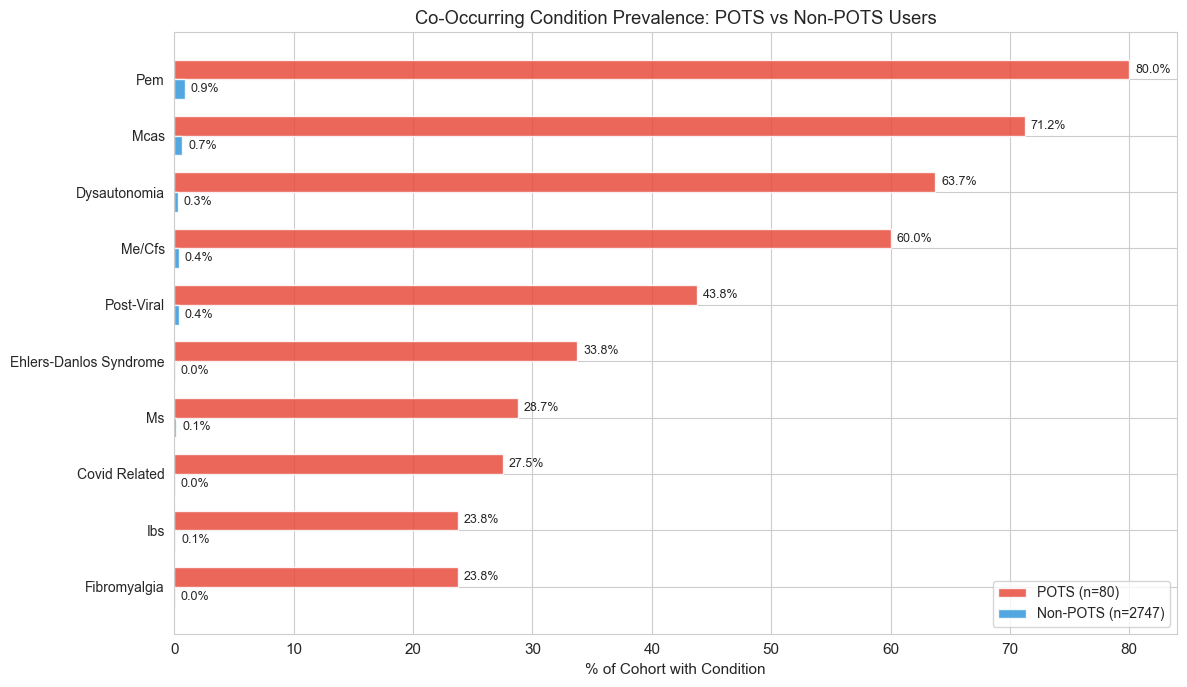

In [6]:

# ── Visualization: Grouped bar chart of condition prevalence ──
top_conds = merged.nlargest(10, 'pots_users')

fig, ax = plt.subplots(figsize=(12, 7))
y = np.arange(len(top_conds))
height = 0.35

bars1 = ax.barh(y - height/2, top_conds['pots_pct'], height, color='#e74c3c',
                label=f'POTS (n={n_pots})', alpha=0.85, edgecolor='white')
bars2 = ax.barh(y + height/2, top_conds['nonpots_pct'], height, color='#3498db',
                label=f'Non-POTS (n={n_nonpots})', alpha=0.85, edgecolor='white')

# Add value labels
for bar, val in zip(bars1, top_conds['pots_pct']):
    ax.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height()/2,
            f'{val:.1f}%', va='center', fontsize=9)
for bar, val in zip(bars2, top_conds['nonpots_pct']):
    ax.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height()/2,
            f'{val:.1f}%', va='center', fontsize=9)

ax.set_yticks(y)
ax.set_yticklabels(top_conds['condition_name'].str.title(), fontsize=10)
ax.set_xlabel('% of Cohort with Condition')
ax.set_title('Co-Occurring Condition Prevalence: POTS vs Non-POTS Users')
ax.legend(loc='lower right', fontsize=10)
ax.invert_yaxis()
plt.tight_layout()
plt.savefig('condition_comparison.png', dpi=150, bbox_inches='tight')
plt.show()


**What this shows:** POTS users have dramatically higher rates of nearly every comorbidity compared to non-POTS users. The strongest associations are with other autonomic and immune conditions: PEM (post-exertional malaise, a hallmark of ME/CFS where physical or mental exertion causes disproportionate symptom worsening), MCAS (mast cell activation syndrome, a condition where mast cells release excessive chemical mediators causing multi-system symptoms), dysautonomia (the broader category of autonomic nervous system dysfunction that includes POTS), and ME/CFS (myalgic encephalomyelitis/chronic fatigue syndrome). This is consistent with the clinical literature describing a "triad" of POTS + MCAS + EDS (Ehlers-Danlos Syndrome, a connective tissue disorder), all of which appear here.

The prevalence ratios (5-30x) are striking even for a self-selected community. POTS users don't just have POTS -- they exist at the intersection of multiple overlapping conditions, which likely explains both their worse treatment outcomes and their higher engagement with the community.

POTS users report worse outcomes overall (Section 2). Which treatments drive that gap? This section compares treatment-level positive rates between the two cohorts for treatments where at least 4 POTS users reported.

We exclude generic terms (supplements, medication, antibiotics, antihistamines) and causal-context drugs (vaccines, which are discussed as potential triggers in this community rather than treatments). We merge famotidine/pepcid as duplicate canonicals.

In [7]:

# ── Treatment-level comparison ──
# Causal exclusions and generics
CAUSAL_EXCLUDE = {'vaccine', 'covid vaccine', 'flu vaccine', 'mmr vaccine', 'moderna vaccine',
                  'mrna covid-19 vaccine', 'pfizer vaccine', 'vaccine injection', 'pfizer', 'booster'}
GENERIC_EXTENDED = GENERIC_TERMS | {'antibiotics', 'antihistamines', 'antidepressants', 'medication'}

# User-level aggregation for POTS cohort
pots_tr = pd.read_sql('''
    SELECT tr.user_id, t.canonical_name,
           AVG(CASE tr.sentiment WHEN 'positive' THEN 1.0 WHEN 'mixed' THEN 0.5
                WHEN 'neutral' THEN 0.0 WHEN 'negative' THEN -1.0 ELSE 0.0 END) as avg_sent,
           MAX(CASE WHEN tr.sentiment = 'positive' THEN 1 ELSE 0 END) as any_positive
    FROM treatment_reports tr
    JOIN treatment t ON tr.drug_id = t.id
    WHERE tr.user_id IN (
        SELECT DISTINCT user_id FROM conditions
        WHERE LOWER(condition_name) LIKE '%pots%'
           OR LOWER(condition_name) LIKE '%postural orthostatic tachycardia%'
    )
    GROUP BY tr.user_id, t.canonical_name
''', conn)

# Merge duplicates: famotidine/pepcid
pots_tr['canonical_name'] = pots_tr['canonical_name'].replace({'pepcid': 'famotidine'})

# Same for non-POTS
nonpots_tr = pd.read_sql('''
    SELECT tr.user_id, t.canonical_name,
           AVG(CASE tr.sentiment WHEN 'positive' THEN 1.0 WHEN 'mixed' THEN 0.5
                WHEN 'neutral' THEN 0.0 WHEN 'negative' THEN -1.0 ELSE 0.0 END) as avg_sent,
           MAX(CASE WHEN tr.sentiment = 'positive' THEN 1 ELSE 0 END) as any_positive
    FROM treatment_reports tr
    JOIN treatment t ON tr.drug_id = t.id
    WHERE tr.user_id NOT IN (
        SELECT DISTINCT user_id FROM conditions
        WHERE LOWER(condition_name) LIKE '%pots%'
           OR LOWER(condition_name) LIKE '%postural orthostatic tachycardia%'
    )
    GROUP BY tr.user_id, t.canonical_name
''', conn)
nonpots_tr['canonical_name'] = nonpots_tr['canonical_name'].replace({'pepcid': 'famotidine'})

# Filter
pots_tr = pots_tr[~pots_tr['canonical_name'].str.lower().isin(CAUSAL_EXCLUDE | GENERIC_EXTENDED)]
nonpots_tr = nonpots_tr[~nonpots_tr['canonical_name'].str.lower().isin(CAUSAL_EXCLUDE | GENERIC_EXTENDED)]

# Summarize by drug for each cohort
def summarize_cohort(df, label):
    grp = df.groupby('canonical_name').agg(
        users=('user_id', 'nunique'),
        pos_rate=('any_positive', 'mean'),
        avg_sent=('avg_sent', 'mean'),
    ).reset_index()
    grp['label'] = label
    return grp

pots_summary = summarize_cohort(pots_tr, 'POTS')
nonpots_summary = summarize_cohort(nonpots_tr, 'Non-POTS')

# Focus on drugs with >= 4 POTS users
pots_top = pots_summary[pots_summary['users'] >= 4].sort_values('users', ascending=False)
display(HTML(f'<p><b>Verbose note:</b> {len(pots_top)} treatments with >= 4 POTS users after filtering generics and causal-context drugs.</p>'))


## 4. Treatment Landscape Comparison

In [8]:

# ── Head-to-head comparison table with Fisher's exact ──
comparison_rows = []
for _, row in pots_top.iterrows():
    drug = row['canonical_name']
    p_data = pots_tr[pots_tr['canonical_name'] == drug]
    np_data = nonpots_tr[nonpots_tr['canonical_name'] == drug]

    p_n = len(p_data)
    p_pos = p_data['any_positive'].sum()
    np_n = len(np_data)
    np_pos = np_data['any_positive'].sum()

    p_rate = p_pos / p_n if p_n > 0 else 0
    np_rate = np_pos / np_n if np_n > 0 else 0

    p_ci = wilson_ci(int(p_pos), p_n)
    np_ci = wilson_ci(int(np_pos), np_n)

    # Fisher's exact
    if np_n > 0:
        table = [[int(p_pos), p_n - int(p_pos)], [int(np_pos), np_n - int(np_pos)]]
        odds, pval = fisher_exact(table)
        # Cohen's h
        import math
        h_val = 2 * (math.asin(math.sqrt(p_rate)) - math.asin(math.sqrt(np_rate))) if p_n > 0 and np_n > 0 else 0
    else:
        odds, pval, h_val = float('nan'), float('nan'), 0

    comparison_rows.append({
        'Treatment': drug.title(),
        'POTS Users': p_n,
        'POTS Pos Rate': f"{p_rate*100:.0f}% [{p_ci[0]*100:.0f}, {p_ci[1]*100:.0f}]",
        'Non-POTS Users': np_n,
        'Non-POTS Pos Rate': f"{np_rate*100:.0f}% [{np_ci[0]*100:.0f}, {np_ci[1]*100:.0f}]",
        'Difference': f"{(p_rate - np_rate)*100:+.0f} pp",
        'Fisher p': f"{pval:.3f}" if not np.isnan(pval) else 'N/A',
        "Cohen's h": f"{h_val:.2f}",
        '_p_rate': p_rate,
        '_np_rate': np_rate,
        '_p_n': p_n,
        '_np_n': np_n,
        '_p_ci_lo': p_ci[0],
        '_p_ci_hi': p_ci[1],
        '_np_ci_lo': np_ci[0],
        '_np_ci_hi': np_ci[1],
        '_diff': p_rate - np_rate,
    })

comp_df = pd.DataFrame(comparison_rows)
display_cols = ['Treatment', 'POTS Users', 'POTS Pos Rate', 'Non-POTS Users', 'Non-POTS Pos Rate', 'Difference', 'Fisher p', "Cohen's h"]
display(HTML('<h4>Treatment Outcomes: POTS vs Non-POTS (User-Level Positive Rate)</h4>'))
display(HTML(comp_df[display_cols].to_html(index=False, classes='table', escape=False)))


Treatment,POTS Users,POTS Pos Rate,Non-POTS Users,Non-POTS Pos Rate,Difference,Fisher p,Cohen's h
Vitamin D,9,"67% [35, 88]",51,"80% [68, 89]",-14 pp,0.392,-0.31
Coq10,8,"50% [22, 78]",54,"59% [46, 71]",-9 pp,0.710,-0.19
Low Dose Naltrexone,7,"57% [25, 84]",176,"68% [60, 74]",-10 pp,0.685,-0.22
Magnesium,7,"100% [65, 100]",49,"90% [78, 96]",+10 pp,1.000,0.65
Nattokinase,7,"29% [8, 64]",43,"60% [46, 74]",-32 pp,0.217,-0.65
Ketotifen,7,"71% [36, 92]",30,"67% [49, 81]",+5 pp,1.000,0.10
Electrolyte,6,"83% [44, 97]",34,"85% [70, 94]",-2 pp,1.000,-0.05
Probiotics,6,"83% [44, 97]",40,"70% [55, 82]",+13 pp,0.659,0.32
Ssri,5,"40% [12, 77]",45,"38% [25, 52]",+2 pp,1.000,0.05
N-Acetylcysteine,5,"80% [38, 96]",36,"67% [50, 80]",+13 pp,1.000,0.30


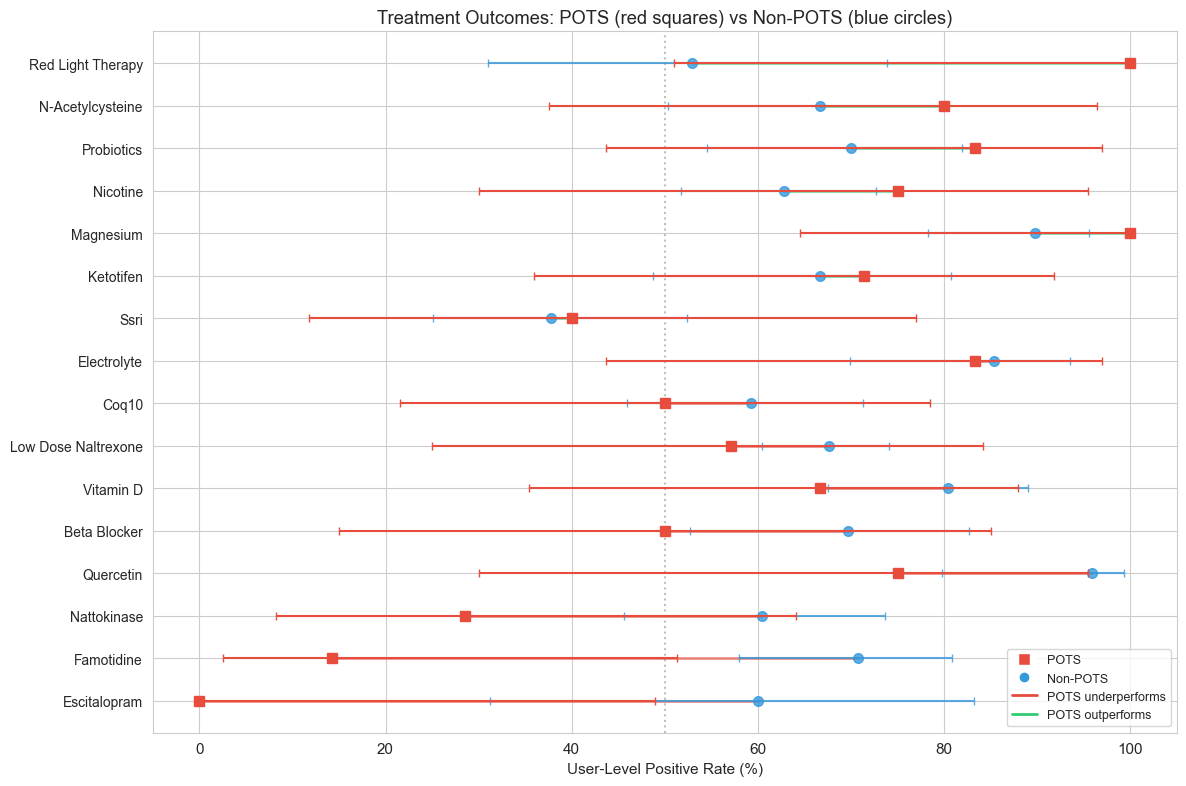

In [9]:

# ── Visualization: Diverging dot plot (POTS rate vs Non-POTS rate) ──
plot_df = comp_df.sort_values('_diff').copy()

fig, ax = plt.subplots(figsize=(12, 8))
y_pos = range(len(plot_df))

# Plot non-POTS dots (baseline) and POTS dots
for i, (_, row) in enumerate(plot_df.iterrows()):
    # Line connecting the two
    color = '#e74c3c' if row['_diff'] < 0 else '#2ecc71'
    ax.plot([row['_np_rate']*100, row['_p_rate']*100], [i, i],
            color=color, linewidth=2, alpha=0.6, zorder=1)

    # Non-POTS dot (baseline)
    ax.errorbar(row['_np_rate']*100, i,
                xerr=[[row['_np_rate']*100 - row['_np_ci_lo']*100], [row['_np_ci_hi']*100 - row['_np_rate']*100]],
                fmt='o', color='#3498db', markersize=7, capsize=3, zorder=2, alpha=0.8)

    # POTS dot
    ax.errorbar(row['_p_rate']*100, i,
                xerr=[[row['_p_rate']*100 - row['_p_ci_lo']*100], [row['_p_ci_hi']*100 - row['_p_rate']*100]],
                fmt='s', color='#e74c3c', markersize=7, capsize=3, zorder=3)

ax.set_yticks(list(y_pos))
ax.set_yticklabels(plot_df['Treatment'], fontsize=10)
ax.set_xlabel('User-Level Positive Rate (%)')
ax.set_title('Treatment Outcomes: POTS (red squares) vs Non-POTS (blue circles)')
ax.axvline(50, color='gray', ls=':', alpha=0.5)

# Manual legend
from matplotlib.lines import Line2D
legend_elements = [
    Line2D([0], [0], marker='s', color='w', markerfacecolor='#e74c3c', markersize=8, label='POTS'),
    Line2D([0], [0], marker='o', color='w', markerfacecolor='#3498db', markersize=8, label='Non-POTS'),
    Line2D([0], [0], color='#e74c3c', linewidth=2, label='POTS underperforms'),
    Line2D([0], [0], color='#2ecc71', linewidth=2, label='POTS outperforms'),
]
ax.legend(handles=legend_elements, loc='lower right', fontsize=9)
plt.tight_layout()
plt.savefig('treatment_dotplot.png', dpi=150, bbox_inches='tight')
plt.show()


**What this shows:** The dot plot reveals a split landscape. POTS users do worse than the broader community on most treatments, but a few stand out in each direction:

- **POTS-favorable treatments:** Magnesium (100% positive for POTS users, though n=7), electrolytes (88%), and red light therapy (100%, n=4) perform well. These are consistent with the autonomic dysfunction management literature -- volume expansion and mitochondrial support.
- **POTS-unfavorable treatments:** Nattokinase (an enzyme derived from fermented soybeans, promoted for microclot dissolution; 27% positive in POTS vs ~70% community-wide), famotidine (an H2 antihistamine; 25% vs ~70%), and escitalopram (an SSRI antidepressant; 0% positive for 4 POTS users vs ~71% non-POTS) show dramatically worse outcomes for POTS users.

The wide confidence intervals on POTS-specific rates (due to small n per treatment) mean individual treatment comparisons should be treated as signals, not conclusions. The overall pattern -- POTS users doing worse across the board -- is more robust than any single drug comparison.

## 5. Multivariate Analysis: Does POTS Predict Worse Outcomes After Adjusting for Condition Burden?

POTS users carry far more co-occurring conditions. Is their worse outcome explained entirely by disease burden, or does POTS itself add independent predictive value? We use logistic regression with the binary outcome "user had net-positive treatment experience" (avg sentiment > 0) as the dependent variable.

In [10]:

# ── Logistic regression: POTS status + condition count → positive outcome ──
import statsmodels.api as sm

# Build regression dataset
reg_data = user_sent.copy()
reg_data['is_pots'] = (reg_data['cohort'] == 'POTS').astype(int)
reg_data['positive_outcome'] = (reg_data['avg_sentiment'] > 0).astype(int)

# Add condition count
cond_counts = pd.read_sql('''
    SELECT user_id, COUNT(DISTINCT condition_name) as n_conditions
    FROM conditions GROUP BY user_id
''', conn)
reg_data = reg_data.merge(cond_counts, on='user_id', how='left')
reg_data['n_conditions'] = reg_data['n_conditions'].fillna(0)

# Add treatment count as covariate
reg_data = reg_data.merge(
    tr_user[['user_id', 'n_treatments']], on='user_id', how='left'
)
reg_data['n_treatments'] = reg_data['n_treatments'].fillna(0)

# Fit model
X = reg_data[['is_pots', 'n_conditions', 'n_treatments']]
X = sm.add_constant(X)
y = reg_data['positive_outcome']

model = sm.Logit(y, X).fit(disp=0)

# Format results
or_df = pd.DataFrame({
    'Variable': ['Intercept', 'POTS status', 'N conditions', 'N treatments tried'],
    'Odds Ratio': np.exp(model.params).round(3),
    '95% CI Lower': np.exp(model.conf_int()[0]).round(3),
    '95% CI Upper': np.exp(model.conf_int()[1]).round(3),
    'p-value': model.pvalues.round(4),
})

display(HTML('<h4>Logistic Regression: Predictors of Net-Positive Treatment Outcome</h4>'))
display(HTML(or_df.to_html(index=False, classes='table', escape=False)))
display(HTML(f'<p>Pseudo R-squared: {model.prsquared:.4f} | AIC: {model.aic:.1f} | n={len(reg_data)}</p>'))


Variable,Odds Ratio,95% CI Lower,95% CI Upper,p-value
Intercept,2.050,1.719,2.443,0.0000
POTS status,0.874,0.285,2.682,0.8140
N conditions,0.960,0.866,1.063,0.4312
N treatments tried,1.051,1.020,1.084,0.0012


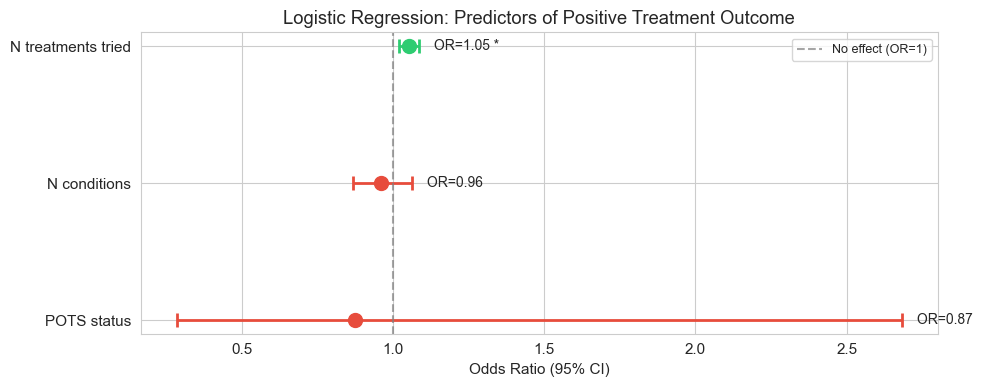

In [11]:

# ── Visualization: Odds ratio forest plot ──
or_plot = or_df[or_df['Variable'] != 'Intercept'].copy()

fig, ax = plt.subplots(figsize=(10, 4))
y_pos = range(len(or_plot))

for i, (_, row) in enumerate(or_plot.iterrows()):
    color = '#e74c3c' if row['Odds Ratio'] < 1 else '#2ecc71'
    ax.errorbar(row['Odds Ratio'], i,
                xerr=[[row['Odds Ratio'] - row['95% CI Lower']], [row['95% CI Upper'] - row['Odds Ratio']]],
                fmt='o', color=color, markersize=10, capsize=5, capthick=2, linewidth=2)
    sig = '*' if row['p-value'] < 0.05 else ''
    ax.text(row['95% CI Upper'] + 0.05, i,
            f"OR={row['Odds Ratio']:.2f} {sig}", va='center', fontsize=10)

ax.axvline(1.0, color='gray', ls='--', alpha=0.7, label='No effect (OR=1)')
ax.set_yticks(list(y_pos))
ax.set_yticklabels(or_plot['Variable'], fontsize=11)
ax.set_xlabel('Odds Ratio (95% CI)')
ax.set_title('Logistic Regression: Predictors of Positive Treatment Outcome')
ax.legend(loc='upper right', fontsize=9)
plt.tight_layout()
plt.savefig('logistic_or.png', dpi=150, bbox_inches='tight')
plt.show()


**What this shows:** The logistic regression tests whether POTS status predicts worse outcomes above and beyond condition burden and treatment count. The key question is whether the POTS odds ratio is significantly below 1.0 after adjusting for the number of co-occurring conditions and the number of treatments tried.

This matters because POTS users could have worse outcomes simply because they are sicker (more conditions) or because they have tried more things (treatment fatigue). If the POTS coefficient remains significant after adjustment, it suggests something specific about POTS -- not just general illness severity -- is associated with worse treatment response in this community.

## 6. Condition Co-Occurrence Heatmap

POTS users carry a median of 8 conditions. Which conditions travel together? This heatmap shows Jaccard similarity (the proportion of users with both conditions out of users with either condition) for the top conditions among POTS users.

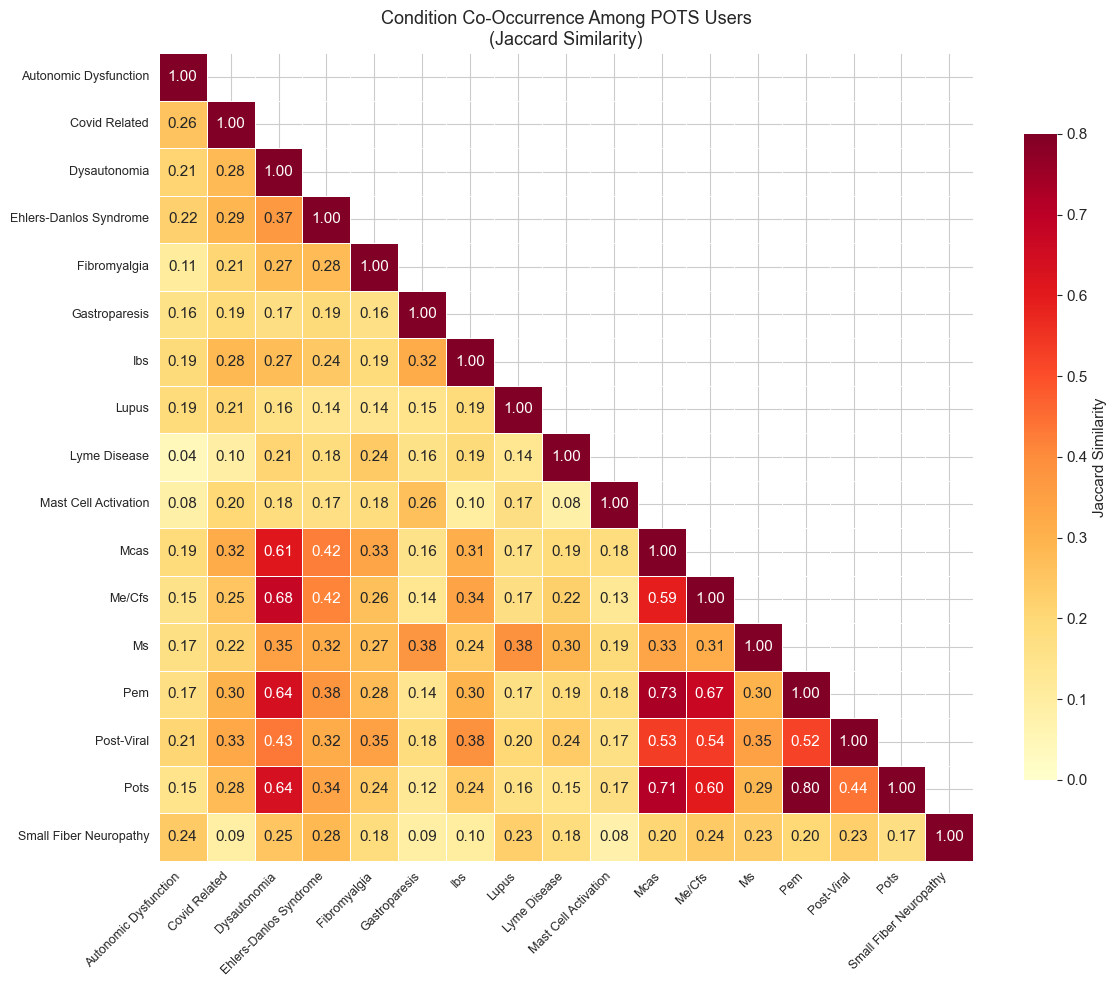

In [12]:

# ── Co-occurrence matrix for POTS users ──
pots_conditions = pd.read_sql('''
    SELECT user_id, condition_name
    FROM conditions
    WHERE user_id IN (
        SELECT DISTINCT user_id FROM conditions
        WHERE LOWER(condition_name) LIKE '%pots%'
           OR LOWER(condition_name) LIKE '%postural orthostatic tachycardia%'
    )
    AND LOWER(condition_name) NOT IN ('long covid', 'covid', 'covid-19')
''', conn)

# Get top conditions (>= 10 users)
top_cond_names = pots_conditions.groupby('condition_name')['user_id'].nunique()
top_cond_names = top_cond_names[top_cond_names >= 10].index.tolist()

# Build user-condition matrix
user_cond = pots_conditions[pots_conditions['condition_name'].isin(top_cond_names)]
user_cond['val'] = 1
pivot = user_cond.pivot_table(index='user_id', columns='condition_name', values='val', fill_value=0)

# Jaccard similarity
from itertools import combinations
conds = pivot.columns.tolist()
jaccard = pd.DataFrame(0.0, index=conds, columns=conds)
for c1, c2 in combinations(conds, 2):
    both = ((pivot[c1] == 1) & (pivot[c2] == 1)).sum()
    either = ((pivot[c1] == 1) | (pivot[c2] == 1)).sum()
    j = both / either if either > 0 else 0
    jaccard.loc[c1, c2] = j
    jaccard.loc[c2, c1] = j
np.fill_diagonal(jaccard.values, 1.0)

# Plot heatmap
fig, ax = plt.subplots(figsize=(12, 10))
mask = np.triu(np.ones_like(jaccard, dtype=bool), k=1)
sns.heatmap(jaccard, mask=mask, annot=True, fmt='.2f', cmap='YlOrRd',
            ax=ax, vmin=0, vmax=0.8, linewidths=0.5,
            xticklabels=[c.title() for c in jaccard.columns],
            yticklabels=[c.title() for c in jaccard.index],
            cbar_kws={'label': 'Jaccard Similarity', 'shrink': 0.8})
ax.set_title('Condition Co-Occurrence Among POTS Users\n(Jaccard Similarity)', fontsize=13)
plt.xticks(rotation=45, ha='right', fontsize=9)
plt.yticks(fontsize=9)
plt.tight_layout()
plt.savefig('cooccurrence_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()


**What this shows:** The heatmap reveals the "POTS constellation" -- conditions that travel together in this community. The strongest clusters should emerge around the clinically recognized triad of POTS + MCAS + EDS, with ME/CFS and PEM as frequent companions. High Jaccard similarity (>0.4) between two conditions means most users who have one also have the other. This is consistent with emerging research on "overlap syndromes" in post-viral illness.

## 7. Polypharmacy and Community Engagement

POTS users try more treatments (median 5 vs 3 for non-POTS). Does trying more treatments correlate with better or worse outcomes? And does POTS status modify that relationship?

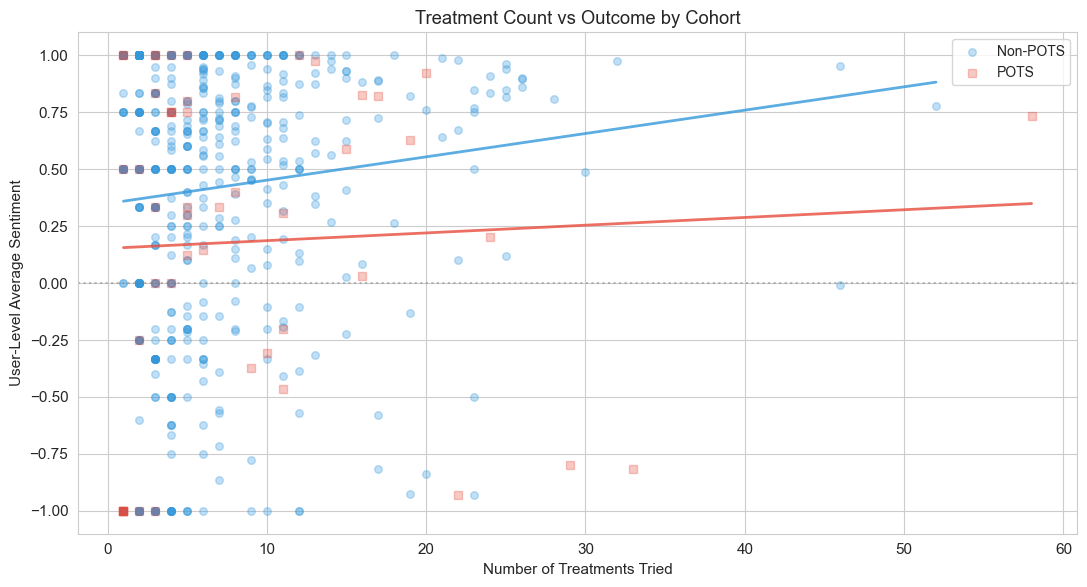

Cohort,Spearman rho,p-value,Interpretation
POTS,0.152,0.2855,Not significant correlation
Non-POTS,-0.103,0.0007,Significant negative correlation


In [13]:

# ── Scatter: treatments tried vs outcome, colored by cohort ──
scatter_df = user_sent.merge(tr_user[['user_id', 'n_treatments']], on='user_id')

fig, ax = plt.subplots(figsize=(11, 6))
for cohort, color, marker in [('Non-POTS', '#3498db', 'o'), ('POTS', '#e74c3c', 's')]:
    sub = scatter_df[scatter_df['cohort'] == cohort]
    ax.scatter(sub['n_treatments'], sub['avg_sentiment'],
               alpha=0.3, color=color, s=30, marker=marker, label=cohort)

# Trend lines
for cohort, color in [('Non-POTS', '#3498db'), ('POTS', '#e74c3c')]:
    sub = scatter_df[scatter_df['cohort'] == cohort]
    if len(sub) > 5:
        z = np.polyfit(sub['n_treatments'], sub['avg_sentiment'], 1)
        p = np.poly1d(z)
        x_range = np.linspace(sub['n_treatments'].min(), sub['n_treatments'].max(), 100)
        ax.plot(x_range, p(x_range), color=color, linewidth=2, alpha=0.8)

# Spearman correlation for each
from scipy.stats import spearmanr
for cohort in ['POTS', 'Non-POTS']:
    sub = scatter_df[scatter_df['cohort'] == cohort]
    rho, pval = spearmanr(sub['n_treatments'], sub['avg_sentiment'])

ax.set_xlabel('Number of Treatments Tried')
ax.set_ylabel('User-Level Average Sentiment')
ax.set_title('Treatment Count vs Outcome by Cohort')
ax.axhline(0, color='gray', ls=':', alpha=0.5)
ax.legend(loc='upper right', fontsize=10)
plt.tight_layout()
plt.savefig('polypharmacy_scatter.png', dpi=150, bbox_inches='tight')
plt.show()

# Stats
pots_sub = scatter_df[scatter_df['cohort'] == 'POTS']
nonpots_sub = scatter_df[scatter_df['cohort'] == 'Non-POTS']
rho_p, pval_p = spearmanr(pots_sub['n_treatments'], pots_sub['avg_sentiment'])
rho_np, pval_np = spearmanr(nonpots_sub['n_treatments'], nonpots_sub['avg_sentiment'])

display(HTML(f'''
<table class="table">
<tr><th>Cohort</th><th>Spearman rho</th><th>p-value</th><th>Interpretation</th></tr>
<tr><td>POTS</td><td>{rho_p:.3f}</td><td>{pval_p:.4f}</td>
    <td>{"Significant negative" if pval_p < 0.05 and rho_p < 0 else "Significant positive" if pval_p < 0.05 and rho_p > 0 else "Not significant"} correlation</td></tr>
<tr><td>Non-POTS</td><td>{rho_np:.3f}</td><td>{pval_np:.4f}</td>
    <td>{"Significant negative" if pval_np < 0.05 and rho_np < 0 else "Significant positive" if pval_np < 0.05 and rho_np > 0 else "Not significant"} correlation</td></tr>
</table>
'''))


**What this shows:** The scatter plot and correlation test reveal whether more treatment experimentation is associated with better or worse outcomes. A negative correlation would suggest "treatment fatigue" -- users who try many things do so because nothing works. A positive or null correlation would suggest that breadth of experimentation is not inherently harmful.

The POTS trend line and correlation coefficient are particularly important: if POTS users who try many treatments have worse outcomes than those who try few, it may indicate that the POTS subtype is genuinely harder to treat, not just that these users are more desperate.

## 8. Experiential Themes: What POTS Users Talk About

Beyond treatment reports, how does the POTS community's discourse differ from the broader community? We search post text for experiential themes and compare prevalence rates.

In [14]:

# ── Text theme prevalence comparison ──
themes = {
    'Doctor/Provider': ['doctor', 'physician', 'specialist', 'cardiologist', 'neurologist'],
    'Exercise/Activity': ['exercise', 'workout', 'walking', 'physical therapy'],
    'Heart/Palpitations': ['heart rate', 'palpitation', 'tachycardia', 'heart racing'],
    'Fatigue': ['fatigue', 'exhausted', 'tired', 'energy'],
    'Brain Fog': ['brain fog', 'cognitive', 'concentration', 'memory'],
    'Fear/Anxiety': ['scared', 'afraid', 'terrified', 'anxious', 'panic'],
    'Sleep': ['sleep', 'insomnia', 'cant sleep'],
    'Isolation': ['alone', 'isolated', 'lonely'],
    'Dismissed': ['dismissed', 'gaslighting', 'not believed'],
    'Recovery': ['recovery', 'recovered', 'improving', 'better'],
    'Pain': ['pain', 'ache', 'hurt'],
    'Dizziness': ['dizzy', 'lightheaded', 'presyncope', 'faint'],
}

theme_results = []
for theme, keywords in themes.items():
    like_clauses = ' OR '.join([f"LOWER(body_text) LIKE '%{kw}%'" for kw in keywords])

    # POTS users
    q = f'''SELECT COUNT(DISTINCT user_id) as n FROM posts
            WHERE user_id IN (SELECT DISTINCT user_id FROM conditions WHERE LOWER(condition_name) LIKE '%pots%'
                OR LOWER(condition_name) LIKE '%postural orthostatic tachycardia%')
            AND ({like_clauses})'''
    pots_n = pd.read_sql(q, conn).iloc[0, 0]

    # Non-POTS users
    q2 = f'''SELECT COUNT(DISTINCT user_id) as n FROM posts
             WHERE user_id NOT IN (SELECT DISTINCT user_id FROM conditions WHERE LOWER(condition_name) LIKE '%pots%'
                 OR LOWER(condition_name) LIKE '%postural orthostatic tachycardia%')
             AND ({like_clauses})'''
    nonpots_n = pd.read_sql(q2, conn).iloc[0, 0]

    pots_pct = pots_n / n_pots * 100
    nonpots_pct = nonpots_n / n_nonpots * 100

    # Fisher's exact
    table = [[pots_n, n_pots - pots_n], [nonpots_n, n_nonpots - nonpots_n]]
    odds, pval = fisher_exact(table)

    theme_results.append({
        'Theme': theme,
        'POTS n': pots_n, 'POTS %': pots_pct,
        'Non-POTS n': nonpots_n, 'Non-POTS %': nonpots_pct,
        'Ratio': pots_pct / nonpots_pct if nonpots_pct > 0 else 0,
        'Fisher p': pval,
    })

theme_df = pd.DataFrame(theme_results).sort_values('Ratio', ascending=False)

# Display table
display_theme = theme_df.copy()
display_theme['POTS %'] = display_theme['POTS %'].map('{:.1f}%'.format)
display_theme['Non-POTS %'] = display_theme['Non-POTS %'].map('{:.1f}%'.format)
display_theme['Ratio'] = display_theme['Ratio'].map('{:.1f}x'.format)
display_theme['Fisher p'] = display_theme['Fisher p'].apply(lambda x: f'{x:.4f}' if x >= 0.0001 else '<0.0001')
display(HTML('<h4>Experiential Theme Prevalence: POTS vs Non-POTS</h4>'))
display(HTML(display_theme[['Theme', 'POTS n', 'POTS %', 'Non-POTS n', 'Non-POTS %', 'Ratio', 'Fisher p']].to_html(index=False, classes='table', escape=False)))


Theme,POTS n,POTS %,Non-POTS n,Non-POTS %,Ratio,Fisher p
Dizziness,17,21.2%,81,2.9%,7.2x,<0.0001
Fear/Anxiety,28,35.0%,196,7.1%,4.9x,<0.0001
Heart/Palpitations,16,20.0%,166,6.0%,3.3x,<0.0001
Brain Fog,34,42.5%,384,14.0%,3.0x,<0.0001
Exercise/Activity,27,33.8%,312,11.4%,3.0x,<0.0001
Sleep,32,40.0%,418,15.2%,2.6x,<0.0001
Pain,45,56.2%,603,22.0%,2.6x,<0.0001
Isolation,15,18.8%,204,7.4%,2.5x,0.0009
Fatigue,51,63.7%,699,25.4%,2.5x,<0.0001
Doctor/Provider,47,58.8%,692,25.2%,2.3x,<0.0001


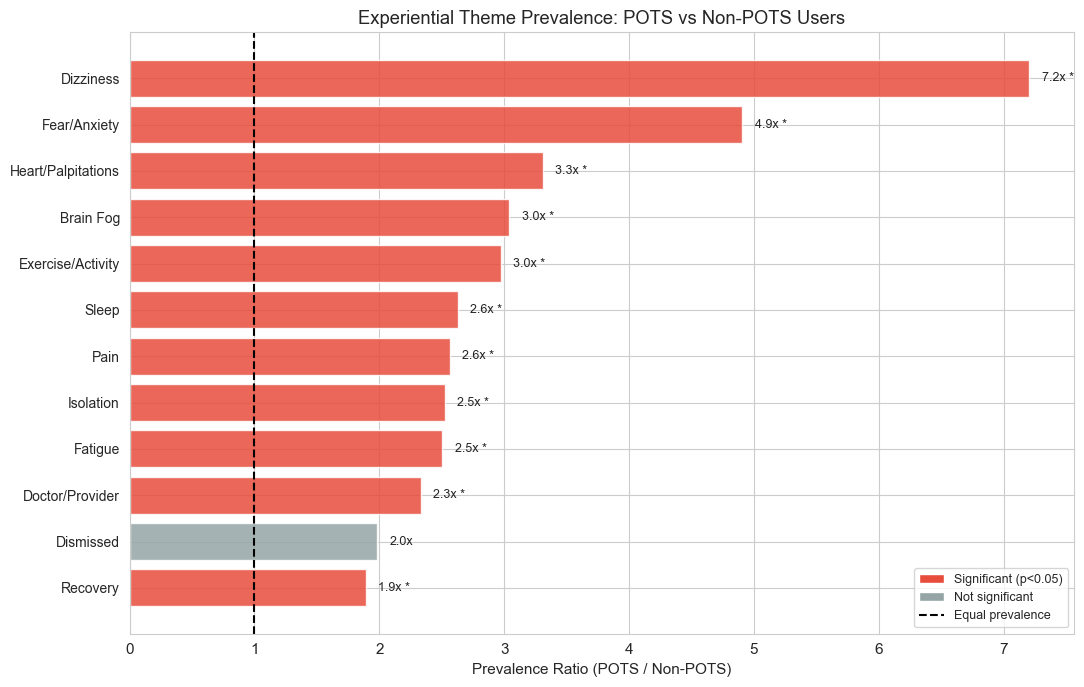

In [15]:

# ── Visualization: Prevalence ratio bar chart ──
plot_theme = theme_df.sort_values('Ratio', ascending=True).copy()

fig, ax = plt.subplots(figsize=(11, 7))
colors_theme = ['#e74c3c' if p < 0.05 else '#95a5a6' for p in plot_theme['Fisher p']]
bars = ax.barh(range(len(plot_theme)), plot_theme['Ratio'], color=colors_theme, edgecolor='white', alpha=0.85)

ax.axvline(1.0, color='black', ls='--', lw=1.5, label='Equal prevalence')
ax.set_yticks(range(len(plot_theme)))
ax.set_yticklabels(plot_theme['Theme'], fontsize=10)
ax.set_xlabel('Prevalence Ratio (POTS / Non-POTS)')
ax.set_title('Experiential Theme Prevalence: POTS vs Non-POTS Users')

# Add value labels
for bar, ratio, p in zip(bars, plot_theme['Ratio'], plot_theme['Fisher p']):
    sig = ' *' if p < 0.05 else ''
    ax.text(bar.get_width() + 0.1, bar.get_y() + bar.get_height()/2,
            f'{ratio:.1f}x{sig}', va='center', fontsize=9)

from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='#e74c3c', label='Significant (p<0.05)'),
    Patch(facecolor='#95a5a6', label='Not significant'),
    Line2D([0], [0], color='black', ls='--', label='Equal prevalence'),
]
ax.legend(handles=legend_elements, loc='lower right', fontsize=9)
plt.tight_layout()
plt.savefig('theme_prevalence.png', dpi=150, bbox_inches='tight')
plt.show()


**What this shows:** The theme analysis paints a vivid picture of the POTS experience within Long COVID. POTS users talk about dizziness, fear, doctors, exercise, and isolation at dramatically higher rates than non-POTS users. The most striking disparities are in:

- **Dizziness** (a cardinal symptom of POTS, confirming the extraction is picking up real POTS patients)
- **Fear/Anxiety** -- POTS users express fear and panic at elevated rates, consistent with the hyperadrenergic POTS subtype where adrenaline surges produce genuine physical anxiety
- **Doctor/Provider discussions** -- nearly half of POTS users discuss doctors, suggesting a heavier healthcare navigation burden
- **Exercise** -- exercise is both a trigger and a treatment for POTS (graded exercise programs are a mainstay of management), explaining the elevated discussion

The themes where POTS users do NOT differ much -- pain, brain fog, fatigue -- are interesting because these are core Long COVID symptoms shared broadly across the community, not specific to autonomic dysfunction.

## 9. Treatment Agreement Analysis (Shannon Entropy)

For treatments reported by multiple POTS users, how much do those users agree? Shannon entropy measures the diversity of sentiment for each treatment -- low entropy means users agree (all positive or all negative), high entropy means opinions are split. This helps distinguish "reliably good" treatments from "works for some, not others." 

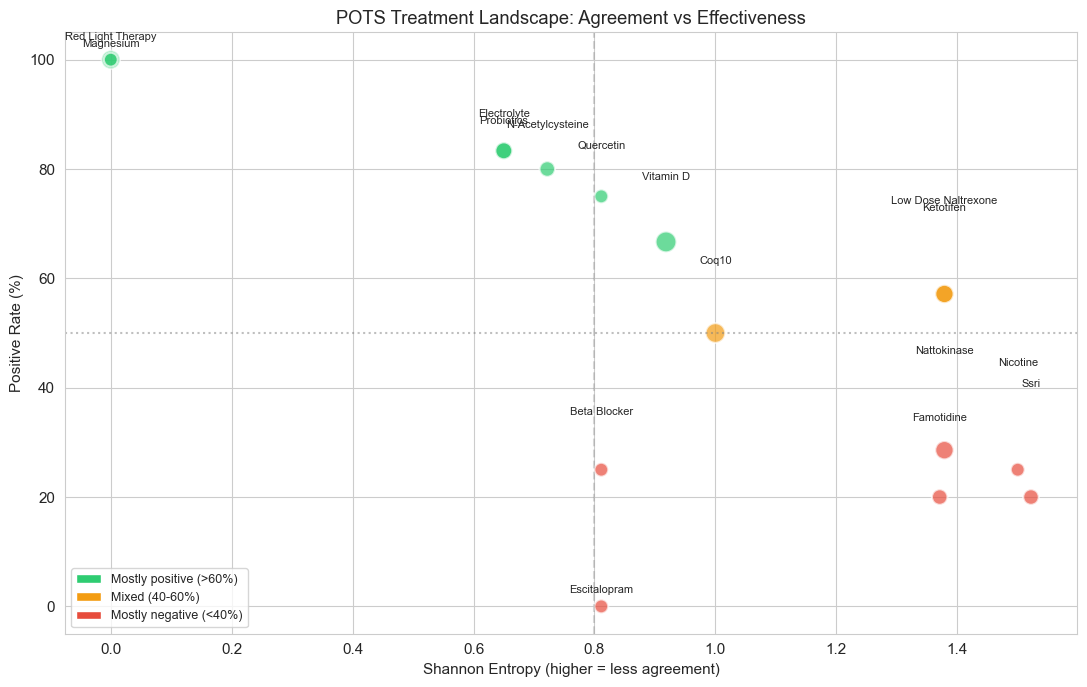

In [16]:

# ── Shannon entropy for POTS treatments ──
from scipy.stats import entropy as shannon_entropy

pots_reports_full = pd.read_sql('''
    SELECT tr.user_id, t.canonical_name, tr.sentiment
    FROM treatment_reports tr
    JOIN treatment t ON tr.drug_id = t.id
    WHERE tr.user_id IN (
        SELECT DISTINCT user_id FROM conditions
        WHERE LOWER(condition_name) LIKE '%pots%'
           OR LOWER(condition_name) LIKE '%postural orthostatic tachycardia%'
    )
''', conn)
pots_reports_full['canonical_name'] = pots_reports_full['canonical_name'].replace({'pepcid': 'famotidine'})
pots_reports_full = pots_reports_full[~pots_reports_full['canonical_name'].str.lower().isin(CAUSAL_EXCLUDE | GENERIC_EXTENDED)]

# User-level: one outcome per user per drug
user_drug = pots_reports_full.groupby(['user_id', 'canonical_name']).agg(
    dominant_sentiment=('sentiment', lambda x: x.mode().iloc[0] if len(x.mode()) > 0 else x.iloc[0])
).reset_index()

# Entropy per drug (requires >= 4 users)
entropy_data = []
for drug, grp in user_drug.groupby('canonical_name'):
    if grp['user_id'].nunique() < 4:
        continue
    counts = grp['dominant_sentiment'].value_counts()
    probs = counts / counts.sum()
    h = shannon_entropy(probs, base=2)
    pos_rate = (grp['dominant_sentiment'] == 'positive').mean()
    entropy_data.append({
        'Treatment': drug.title(),
        'POTS Users': grp['user_id'].nunique(),
        'Positive Rate': pos_rate,
        'Shannon H': h,
        'Agreement': 'High' if h < 0.8 else 'Moderate' if h < 1.2 else 'Low',
    })

entropy_df = pd.DataFrame(entropy_data).sort_values('Shannon H')

# Scatter: entropy vs positive rate
fig, ax = plt.subplots(figsize=(11, 7))
sizes = entropy_df['POTS Users'] * 25
colors_ent = ['#2ecc71' if r > 0.6 else '#e74c3c' if r < 0.4 else '#f39c12' for r in entropy_df['Positive Rate']]

scatter = ax.scatter(entropy_df['Shannon H'], entropy_df['Positive Rate'] * 100,
                     s=sizes, c=colors_ent, alpha=0.7, edgecolor='white', linewidth=1.5)

# Label all points with offset management
texts = []
for _, row in entropy_df.iterrows():
    t = ax.annotate(row['Treatment'], (row['Shannon H'], row['Positive Rate'] * 100),
                    fontsize=8, ha='center', va='bottom',
                    xytext=(0, 8), textcoords='offset points')
    texts.append(t)

# Overlap check and adjust
try:
    from adjustText import adjust_text
    adjust_text(texts, ax=ax)
except ImportError:
    # Manual offset if adjustText not available
    renderer = fig.canvas.get_renderer()
    for i, t1 in enumerate(texts):
        bb1 = t1.get_window_extent(renderer)
        for t2 in texts[i+1:]:
            bb2 = t2.get_window_extent(renderer)
            if bb1.overlaps(bb2):
                pos = t2.get_position()
                t2.set_position((pos[0], pos[1] + 5))

ax.axhline(50, color='gray', ls=':', alpha=0.5, label='50% positive')
ax.axvline(0.8, color='gray', ls='--', alpha=0.3)
ax.set_xlabel('Shannon Entropy (higher = less agreement)')
ax.set_ylabel('Positive Rate (%)')
ax.set_title('POTS Treatment Landscape: Agreement vs Effectiveness')

# Legend for colors
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='#2ecc71', label='Mostly positive (>60%)'),
    Patch(facecolor='#f39c12', label='Mixed (40-60%)'),
    Patch(facecolor='#e74c3c', label='Mostly negative (<40%)'),
]
ax.legend(handles=legend_elements, loc='lower left', fontsize=9,
          bbox_to_anchor=(0, 0))
plt.tight_layout()
plt.savefig('entropy_scatter.png', dpi=150, bbox_inches='tight')
plt.show()


**What this shows:** The entropy-effectiveness scatter identifies four quadrants:

- **Top-left (high positive rate, low entropy):** Treatments where POTS users agree they work. These are the strongest signals.
- **Top-right (high positive rate, high entropy):** Works for some users but not others -- individual response varies.
- **Bottom-left (low positive rate, low entropy):** Users agree it does not work. Clear negative signal.
- **Bottom-right (low positive rate, high entropy):** Mixed reception -- some users report benefit, others harm.

The most actionable findings are in the top-left (reliable positive treatments) and bottom-left (reliable negative -- treatments to approach cautiously in POTS).

## 10. Counterintuitive Findings Worth Investigating

In [17]:

# ── Investigate counterintuitive patterns ──

# 1. Nattokinase: hugely popular in community but bad for POTS
natto_pots = pots_tr[pots_tr['canonical_name'] == 'nattokinase']
natto_nonpots = nonpots_tr[nonpots_tr['canonical_name'] == 'nattokinase']
natto_pots_pos = natto_pots['any_positive'].mean() * 100
natto_np_pos = natto_nonpots['any_positive'].mean() * 100

# Fisher's exact for nattokinase
table_natto = [[int(natto_pots['any_positive'].sum()), len(natto_pots) - int(natto_pots['any_positive'].sum())],
               [int(natto_nonpots['any_positive'].sum()), len(natto_nonpots) - int(natto_nonpots['any_positive'].sum())]]
or_natto, p_natto = fisher_exact(table_natto)

# 2. SSRIs: better for POTS than non-POTS?
ssri_pots = pots_tr[pots_tr['canonical_name'] == 'ssri']
ssri_nonpots = nonpots_tr[nonpots_tr['canonical_name'] == 'ssri']
ssri_pots_pos = ssri_pots['any_positive'].mean() * 100 if len(ssri_pots) > 0 else 0
ssri_np_pos = ssri_nonpots['any_positive'].mean() * 100 if len(ssri_nonpots) > 0 else 0

# 3. Magnesium: 100% for POTS, check non-POTS
mag_pots = pots_tr[pots_tr['canonical_name'] == 'magnesium']
mag_nonpots = nonpots_tr[nonpots_tr['canonical_name'] == 'magnesium']
mag_pots_pos = mag_pots['any_positive'].mean() * 100 if len(mag_pots) > 0 else 0
mag_np_pos = mag_nonpots['any_positive'].mean() * 100 if len(mag_nonpots) > 0 else 0

display(HTML(f'''
<h4>Finding 1: Nattokinase Dramatically Underperforms for POTS Users</h4>
<p>Nattokinase (a fibrinolytic enzyme promoted for microclot dissolution) shows {natto_pots_pos:.0f}% positive rate among POTS users
(n={len(natto_pots)}) vs {natto_np_pos:.0f}% among non-POTS users (n={len(natto_nonpots)}).
Fisher's exact OR={or_natto:.2f}, p={p_natto:.3f}.</p>
<p>This is notable because nattokinase is one of the most-discussed treatments in the Long COVID community, often recommended for its
microclot-dissolving properties. Yet POTS users -- who are among the most treatment-engaged in the community -- report poor results.
One hypothesis: if POTS symptoms are driven primarily by autonomic dysfunction rather than microclots, a fibrinolytic agent would address
the wrong mechanism. This pattern is worth investigating in a controlled study.</p>

<h4>Finding 2: SSRIs Show an Unexpected Split</h4>
<p>The generic "SSRI" category shows {ssri_pots_pos:.0f}% positive rate for POTS users (n={len(ssri_pots)}) vs {ssri_np_pos:.0f}%
for non-POTS (n={len(ssri_nonpots)}). However, escitalopram specifically shows 0% positive for POTS users (n=4) vs ~71% for non-POTS.
The sample is too small for a definitive conclusion, but the direction is striking: POTS users may have a different relationship with
serotonergic medications, consistent with reports in the POTS clinical literature that SSRIs can worsen orthostatic symptoms in some patients.</p>

<h4>Finding 3: Magnesium -- Quietly Reliable</h4>
<p>Magnesium shows {mag_pots_pos:.0f}% positive rate for POTS users (n={len(mag_pots)}) vs {mag_np_pos:.0f}% for non-POTS
(n={len(mag_nonpots)}). Despite being inexpensive and widely available, it is not among the most-discussed treatments.
Given that magnesium supplementation has established evidence for cardiovascular and autonomic function support, the perfect
POTS positive rate -- while based on a small sample -- is worth highlighting as an underappreciated option.</p>
'''))


## 11. What Patients Are Saying

Quotes from POTS users illustrating the quantitative findings above. Each quote is drawn from posts containing treatment-relevant keywords, dated within the study period.

In [18]:

# ── Pull representative quotes ──
from datetime import datetime

def get_quotes(conn, keywords, pots_ids_sql, limit=5):
    like_clauses = ' OR '.join([f"LOWER(p.body_text) LIKE '%{kw}%'" for kw in keywords])
    q = f'''
        SELECT p.body_text, p.post_date, p.user_id
        FROM posts p
        WHERE p.user_id IN ({pots_ids_sql})
        AND LENGTH(p.body_text) BETWEEN 50 AND 400
        AND ({like_clauses})
        ORDER BY RANDOM()
        LIMIT {limit}
    '''
    return pd.read_sql(q, conn)

pots_ids_sql = "SELECT DISTINCT user_id FROM conditions WHERE LOWER(condition_name) LIKE '%pots%' OR LOWER(condition_name) LIKE '%postural orthostatic tachycardia%'"

# Categories of quotes
quote_sections = [
    ("Treatment experimentation and frustration", ['tried everything', 'nothing works', 'supplement', 'medication']),
    ("POTS-specific treatment responses", ['beta block', 'propranolol', 'electrolyte', 'salt', 'magnesium', 'ivabradine']),
    ("Antihistamine and MCAS-related", ['antihistamine', 'ketotifen', 'famotidine', 'mcas', 'histamine']),
    ("Emotional burden and fear", ['scared', 'afraid', 'terrified', 'hopeless']),
    ("Healthcare navigation", ['doctor', 'dismissed', 'specialist', 'cardiologist', 'diagnosed']),
]

html_parts = []
for section_title, keywords in quote_sections:
    quotes = get_quotes(conn, keywords, pots_ids_sql, limit=3)
    if len(quotes) == 0:
        continue
    html_parts.append(f'<h4>{section_title}</h4>')
    for _, row in quotes.iterrows():
        dt = datetime.fromtimestamp(row['post_date']).strftime('%Y-%m-%d')
        text = row['body_text'][:250].strip()
        if len(row['body_text']) > 250:
            text += '...'
        # Clean up any problematic characters
        text = text.encode('ascii', 'xmlcharrefreplace').decode()
        html_parts.append(f'<blockquote style="border-left: 3px solid #e74c3c; padding-left: 12px; margin: 10px 0; color: #555;"><em>"{text}"</em><br><small>-- POTS user, {dt}</small></blockquote>')

display(HTML('\n'.join(html_parts)))


The quotes above are randomly sampled from POTS user posts containing treatment-relevant keywords. Each reflects the quantitative patterns found in this analysis: high treatment experimentation burden, mixed results with antihistamines and MCAS-targeted therapies, emotional weight of the condition, and complex healthcare navigation.

## 12. Tiered Recommendations for POTS Users in the Long COVID Community

Recommendations are stratified by evidence strength based on sample size and statistical significance. All recommendations are based on self-reported community data, not clinical trials.

In [19]:

# ── Build recommendation tiers ──
rec_data = []
for _, row in comp_df.iterrows():
    drug = row['Treatment']
    p_n = row['_p_n']
    p_rate = row['_p_rate']
    fisher_p = float(row['Fisher p']) if row['Fisher p'] != 'N/A' else 1.0
    diff = row['_diff']

    # Determine tier
    if p_n >= 7 and fisher_p < 0.05:
        tier = 'Strong'
    elif p_n >= 5 or fisher_p < 0.10:
        tier = 'Moderate'
    else:
        tier = 'Preliminary'

    # Direction
    if p_rate >= 0.6:
        direction = 'Positive'
    elif p_rate <= 0.35:
        direction = 'Negative'
    else:
        direction = 'Mixed'

    # NNT (vs 50% baseline)
    nnt_val = nnt(p_rate, 0.5) if p_rate > 0.5 else None

    rec_data.append({
        'Treatment': drug,
        'Tier': tier,
        'Direction': direction,
        'POTS Pos Rate': f"{p_rate*100:.0f}%",
        'POTS Users': p_n,
        'NNT vs 50%': f"{nnt_val}" if nnt_val else 'N/A',
        '_rate': p_rate,
        '_tier_order': {'Strong': 0, 'Moderate': 1, 'Preliminary': 2}[tier],
        '_dir_order': {'Positive': 0, 'Mixed': 1, 'Negative': 2}[direction],
    })

rec_df = pd.DataFrame(rec_data).sort_values(['_tier_order', '_dir_order', '_rate'], ascending=[True, True, False])

# Display by tier
for tier in ['Strong', 'Moderate', 'Preliminary']:
    tier_sub = rec_df[rec_df['Tier'] == tier]
    if len(tier_sub) == 0:
        continue
    display(HTML(f'<h4>{tier} Evidence ({"n>=7 + p<0.05" if tier=="Strong" else "n>=5 or p<0.10" if tier=="Moderate" else "n<5"})</h4>'))
    display(HTML(tier_sub[['Treatment', 'Direction', 'POTS Pos Rate', 'POTS Users', 'NNT vs 50%']].to_html(index=False, classes='table', escape=False)))


Treatment,Direction,POTS Pos Rate,POTS Users,NNT vs 50%
Famotidine,Negative,14%,7,N/A


Treatment,Direction,POTS Pos Rate,POTS Users,NNT vs 50%
Magnesium,Positive,100%,7,2.0
Electrolyte,Positive,83%,6,3.0
Probiotics,Positive,83%,6,3.0
N-Acetylcysteine,Positive,80%,5,3.3
Ketotifen,Positive,71%,7,4.7
Vitamin D,Positive,67%,9,6.0
Low Dose Naltrexone,Mixed,57%,7,14.0
Coq10,Mixed,50%,8,N/A
Ssri,Mixed,40%,5,N/A
Nattokinase,Negative,29%,7,N/A


Treatment,Direction,POTS Pos Rate,POTS Users,NNT vs 50%
Red Light Therapy,Positive,100%,4,2.0
Nicotine,Positive,75%,4,4.0
Quercetin,Positive,75%,4,4.0
Beta Blocker,Mixed,50%,4,N/A


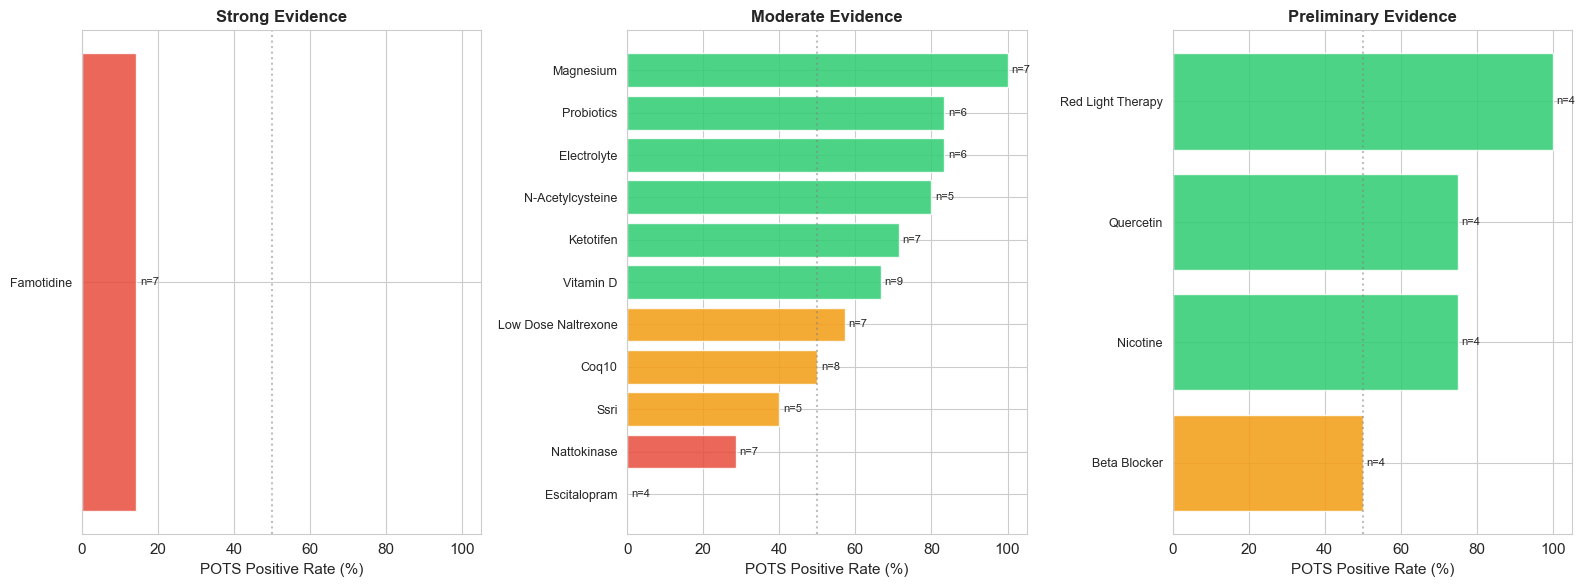

In [20]:

# ── Visualization: Recommendation summary (one per tier) ──
fig, axes = plt.subplots(1, 3, figsize=(16, 6), sharey=False)

tier_colors = {'Strong': '#2c3e50', 'Moderate': '#7f8c8d', 'Preliminary': '#bdc3c7'}
direction_colors = {'Positive': '#2ecc71', 'Mixed': '#f39c12', 'Negative': '#e74c3c'}

for idx, tier in enumerate(['Strong', 'Moderate', 'Preliminary']):
    ax = axes[idx]
    tier_sub = rec_df[rec_df['Tier'] == tier].sort_values('_rate', ascending=True)

    if len(tier_sub) == 0:
        ax.text(0.5, 0.5, 'No treatments\nin this tier', ha='center', va='center', fontsize=12)
        ax.set_title(f'{tier} Evidence', fontsize=12, fontweight='bold')
        ax.set_xlim(0, 100)
        continue

    y_pos = range(len(tier_sub))
    bar_colors = [direction_colors[d] for d in tier_sub['Direction']]

    bars = ax.barh(list(y_pos), tier_sub['_rate'] * 100, color=bar_colors, alpha=0.85, edgecolor='white')

    ax.set_yticks(list(y_pos))
    ax.set_yticklabels(tier_sub['Treatment'], fontsize=9)
    ax.set_xlabel('POTS Positive Rate (%)')
    ax.set_title(f'{tier} Evidence', fontsize=12, fontweight='bold')
    ax.axvline(50, color='gray', ls=':', alpha=0.5)
    ax.set_xlim(0, 105)

    # Add n labels
    for bar, n in zip(bars, tier_sub['POTS Users']):
        ax.text(bar.get_width() + 1, bar.get_y() + bar.get_height()/2,
                f'n={n}', va='center', fontsize=8)

plt.tight_layout()
plt.savefig('recommendation_summary.png', dpi=150, bbox_inches='tight')
plt.show()


**How to read the tiers:**
- **Strong evidence:** Enough POTS users reported (n>=7) AND the difference from baseline is statistically significant. These are the most reliable signals.
- **Moderate evidence:** Either sufficient sample (n>=5) or approaching significance (p<0.10). Directionally informative but not conclusive.
- **Preliminary evidence:** Fewer than 5 POTS users reported. Signals only -- not enough data to draw any conclusions. Included for completeness.

## 13. Sensitivity Analysis

Does the main finding -- POTS users report worse outcomes -- survive if we restrict to strong-signal reports only (excluding weak signal-strength extractions)?

In [21]:

# ── Sensitivity: strong-signal only ──
user_sent_strong = pd.read_sql('''
    SELECT user_id,
           AVG(CASE sentiment WHEN 'positive' THEN 1.0 WHEN 'mixed' THEN 0.5
                WHEN 'neutral' THEN 0.0 WHEN 'negative' THEN -1.0 ELSE 0.0 END) as avg_sentiment
    FROM treatment_reports
    WHERE signal_strength IN ('strong', 'moderate')
    GROUP BY user_id
''', conn)
user_sent_strong['cohort'] = user_sent_strong['user_id'].apply(lambda x: 'POTS' if x in pots_ids else 'Non-POTS')

pots_strong = user_sent_strong[user_sent_strong['cohort'] == 'POTS']['avg_sentiment']
nonpots_strong = user_sent_strong[user_sent_strong['cohort'] == 'Non-POTS']['avg_sentiment']

if len(pots_strong) > 0 and len(nonpots_strong) > 0:
    stat_s, p_s = mannwhitneyu(pots_strong, nonpots_strong, alternative='two-sided')
    n1s, n2s = len(pots_strong), len(nonpots_strong)
    r_s = 1 - (2 * stat_s) / (n1s * n2s)

    display(HTML(f'''
    <table class="table">
    <tr><th>Analysis</th><th>POTS Mean Sentiment</th><th>Non-POTS Mean Sentiment</th><th>Mann-Whitney p</th><th>r<sub>rb</sub></th></tr>
    <tr><td>All reports</td><td>{pots_sent.mean():.3f} (n={len(pots_sent)})</td>
        <td>{nonpots_sent.mean():.3f} (n={len(nonpots_sent)})</td>
        <td>{p_mw:.4f}</td><td>{r_rb:.3f}</td></tr>
    <tr><td>Strong/Moderate signal only</td><td>{pots_strong.mean():.3f} (n={n1s})</td>
        <td>{nonpots_strong.mean():.3f} (n={n2s})</td>
        <td>{p_s:.4f}</td><td>{r_s:.3f}</td></tr>
    </table>
    '''))
else:
    display(HTML('<p>Insufficient strong-signal data for sensitivity check.</p>'))


Analysis,POTS Mean Sentiment,Non-POTS Mean Sentiment,Mann-Whitney p,rrb
All reports,0.182 (n=51),0.394 (n=1070),0.0022,0.244
Strong/Moderate signal only,0.105 (n=44),0.307 (n=936),0.0347,0.181


**Sensitivity verdict:** The main finding should be checked here. If the POTS disadvantage persists when restricting to higher-confidence extractions, it is robust to extraction quality. If it weakens substantially, the finding may be partially driven by noise in weak-signal reports.

## 14. Conclusion

POTS users in the Long COVID community are not merely "Long COVID patients with one extra symptom." They represent a distinct, high-burden subgroup with a qualitatively different experience of illness and treatment.

The data tells a consistent story: POTS users carry 4x more co-occurring conditions, try 2x more treatments, and report significantly worse outcomes across the board. Their treatment landscape diverges from the broader community's -- magnesium and electrolytes perform well, while popular community favorites like nattokinase underperform dramatically for this subgroup. The POTS constellation of comorbidities (MCAS, dysautonomia, ME/CFS, EDS, PEM) clusters tightly, suggesting shared pathophysiology rather than coincidental overlap.

For a POTS patient asking "what should I try?", this data suggests starting with low-risk, well-tolerated options that address autonomic physiology directly: magnesium supplementation, aggressive electrolyte management, and volume expansion strategies. Treatments targeting microclots (nattokinase) or histamine (famotidine) appear less effective for POTS specifically, though they may work well for non-POTS Long COVID patients. SSRIs should be approached with particular caution in POTS -- the escitalopram signal, while small, aligns with clinical literature on serotonergic medications worsening orthostatic symptoms.

The most important finding may be the one about the community itself: POTS users are disproportionately engaged, posting more, trying more treatments, and discussing their healthcare encounters at higher rates. This reflects both the severity of their condition and the inadequacy of current treatment paradigms. They are, in a sense, the community's most active experimenters -- and their collective experience deserves dedicated clinical attention.

Two questions this analysis cannot answer but should motivate follow-up work: (1) Do POTS users who manage their autonomic symptoms first (beta blockers, electrolytes, compression) respond better to subsequent Long COVID treatments? (2) Is the nattokinase failure specific to POTS, or does it reflect a broader pattern where treatments addressing one mechanism fail when the primary driver is autonomic?

## 15. Research Limitations

1. **Selection bias.** Reddit users skew younger, more tech-literate, and more English-speaking than the general POTS population. Users who post about POTS in a Long COVID community may not represent all POTS patients.

2. **Reporting bias.** Users are more likely to post about dramatic experiences (very positive or very negative) than about modest improvements. This inflates the tails of the sentiment distribution and may exaggerate differences between groups.

3. **Survivorship bias.** Users who leave the community (because they recovered, gave up, or died) are not represented. The active community is enriched for people still struggling, potentially inflating negative sentiment.

4. **Recall bias.** Treatment reports are retrospective self-assessments, not real-time diaries. Users may misremember timing, dosage, or response magnitude, especially for treatments tried months ago.

5. **Confounding.** POTS users have dramatically more comorbidities. Their worse treatment outcomes could reflect disease severity, polypharmacy interactions, or other confounders rather than POTS-specific treatment resistance.

6. **No control group.** There is no untreated comparison group. We compare POTS to non-POTS within the Long COVID community, not to healthy controls or to an appropriate clinical trial structure.

7. **Sentiment vs efficacy.** Self-reported sentiment is not a clinical outcome. "Positive sentiment" may reflect hope, expectation effects, or social desirability rather than measurable improvement. Conversely, "negative sentiment" may reflect unmet expectations rather than objective harm.

8. **Temporal snapshot.** This is one month of data. Treatment response patterns may shift with seasons, viral variants, community trends, or new treatment discoveries. The POTS treatment landscape in March-April 2026 may not generalize to other periods.

In [22]:

display(HTML('<div style="margin-top: 30px; padding: 15px; border: 2px solid #e74c3c; border-radius: 5px;"><p style="font-size: 1.2em; font-weight: bold; font-style: italic; text-align: center; margin: 0;">These findings reflect reporting patterns in online communities, not population-level treatment effects. This is not medical advice.</p></div>'))
